### Binary and Ternary Classes in This Study Based on Mohs Hardness Values
Binary
0: (0.991, 5.5]
1: (5.5, 10.0]

Ternary
0: (0.991, 4.0]
1: (4.0, 7.0]
2: (7.0, 10.0]

### List of all Primary Features
- `allelectrons_Total`
- `density_Total`
- `allelectrons_Average`
- `val_e_Average`
- `atomicweight_Average`
- `ionenergy_Average`
- `el_neg_chi_Average`
- `R_vdw_element_Average`
- `R_cov_element_Average`
- `zaratio_Average`
- `density_Average`

### Train and Test Datasets
Train: Artificial_Crystals_Dataset.csv
Test: Mineral_Dataset_Supplementary_Info.csv

### ML Models Used
1. Binary RBF SVC
2. Ternary RBF SVC - OVO
3. Binary RF
4. Ternary RF - multiclass
5. Ternary RF - OVR: 0 versus 1, 2
6. Ternary RF - OVR: 1 versus 0, 2
7. Ternary RF - OVR: 2 versus 0, 1
8. Binary Matern SVC
9. Ternary Matern SVC - OVO

In [10]:
from pathlib import Path
import csv
from typing import Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

In [2]:
FEATURES = [
    "allelectrons_Total",
    "density_Total",
    "allelectrons_Average",
    "val_e_Average",
    "atomicweight_Average",
    "ionenergy_Average",
    "el_neg_chi_Average",
    "R_vdw_element_Average",
    "R_cov_element_Average",
    "zaratio_Average",
    "density_Average",
]

In [3]:
def binary_label_from_value(hardness: float) -> Optional[int]:
    if 0.991 < hardness <= 5.5:
        return 0
    if 5.5 < hardness <= 10.0:
        return 1
    return None


def ternary_label_from_value(hardness: float) -> Optional[int]:
    if 0.991 < hardness <= 4.0:
        return 0
    if 4.0 < hardness <= 7.0:
        return 1
    if 7.0 < hardness <= 10.0:
        return 2
    return None


def load_xy(csv_path: Path, hardness_column: str, label_fn=binary_label_from_value) -> Tuple[np.ndarray, np.ndarray]:
    x_rows = []
    y_rows = []
    with csv_path.open(newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            try:
                hardness = float(row[hardness_column])
                label_value = label_fn(hardness)
                if label_value is None:
                    continue
                feature_vector = [float(row[feature]) for feature in FEATURES]
            except (TypeError, ValueError, KeyError):
                continue
            x_rows.append(feature_vector)
            y_rows.append(label_value)
    return np.array(x_rows, dtype=float), np.array(y_rows, dtype=int)

In [4]:
# Get path and load data
base_dir = Path("/Users/owensizemore/code/duke/aimaterials/m5")
if not base_dir.exists():
    base_dir = Path("m5")

X, y = load_xy(base_dir / "Mineral_Dataset_Supplementary_Info.csv", "Hardness")

### 1: Binary RBF SVC

In [5]:
splitter = StratifiedShuffleSplit(n_splits=500, train_size=2 / 3, test_size=1 / 3, random_state=42)
rbf_svc_binary = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", C=10, gamma="scale", random_state=42)),
    ]
)

precision_scores = []
recall_scores = []
accuracy_scores = []
f1_scores = []
specificity_scores = []

for train_index, test_index in splitter.split(X, y):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    rbf_svc_binary.fit(X_train, y_train)
    y_test_pred = rbf_svc_binary.predict(X_test)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test,
        y_test_pred,
        average="weighted",
        zero_division=0,
    )
    accuracy = accuracy_score(y_test, y_test_pred)

    tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    precision_scores.append(precision)
    recall_scores.append(recall)
    accuracy_scores.append(accuracy)
    f1_scores.append(f1)
    specificity_scores.append(specificity)

metric_series = {
    "precision": np.array(precision_scores),
    "recall": np.array(recall_scores),
    "accuracy": np.array(accuracy_scores),
    "f1": np.array(f1_scores),
    "specificity": np.array(specificity_scores),
}

metric_stats = {
    metric_name: {
        "mean": float(values.mean()),
        "std": float(values.std(ddof=1)),
    }
    for metric_name, values in metric_series.items()
}

model_performance = {
    "rbf_svc_binary": metric_stats,
}

for metric_name in ["precision", "recall", "accuracy", "f1", "specificity"]:
    stats = metric_stats[metric_name]
    print(f"{metric_name.capitalize()}: {stats['mean']:.4f} ± {stats['std']:.4f}")


Precision: 0.8369 ± 0.0236
Recall: 0.8360 ± 0.0239
Accuracy: 0.8360 ± 0.0239
F1: 0.8357 ± 0.0238
Specificity: 0.8798 ± 0.0298


### 2. Ternary RBF SVC - OVO

In [6]:
X_ternary, y_ternary = load_xy(
    base_dir / "Mineral_Dataset_Supplementary_Info.csv",
    "Hardness",
    label_fn=ternary_label_from_value,
)

splitter = StratifiedShuffleSplit(n_splits=500, train_size=2 / 3, test_size=1 / 3, random_state=42)
rbf_svc_ternary = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", C=10, gamma="scale", decision_function_shape="ovo", random_state=42)),
    ]
)

precision_scores = []
recall_scores = []
accuracy_scores = []
f1_scores = []
specificity_scores = []

for train_index, test_index in splitter.split(X_ternary, y_ternary):
    X_train, X_test = X_ternary[train_index], X_ternary[test_index]
    y_train, y_test = y_ternary[train_index], y_ternary[test_index]

    rbf_svc_ternary.fit(X_train, y_train)
    y_test_pred = rbf_svc_ternary.predict(X_test)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test,
        y_test_pred,
        average="weighted",
        zero_division=0,
    )
    accuracy = accuracy_score(y_test, y_test_pred)

    cm = confusion_matrix(y_test, y_test_pred, labels=[0, 1, 2])
    per_class_specificity = []
    for class_idx in range(cm.shape[0]):
        tp = cm[class_idx, class_idx]
        fp = cm[:, class_idx].sum() - tp
        fn = cm[class_idx, :].sum() - tp
        tn = cm.sum() - (tp + fp + fn)
        class_specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        per_class_specificity.append(class_specificity)
    specificity = float(np.mean(per_class_specificity))

    precision_scores.append(precision)
    recall_scores.append(recall)
    accuracy_scores.append(accuracy)
    f1_scores.append(f1)
    specificity_scores.append(specificity)

metric_series_ternary = {
    "precision": np.array(precision_scores),
    "recall": np.array(recall_scores),
    "accuracy": np.array(accuracy_scores),
    "f1": np.array(f1_scores),
    "specificity": np.array(specificity_scores),
}

metric_stats_ternary = {
    metric_name: {
        "mean": float(values.mean()),
        "std": float(values.std(ddof=1)),
    }
    for metric_name, values in metric_series_ternary.items()
}

model_performance["rbf_svc_ternary_ovo"] = metric_stats_ternary

for metric_name in ["precision", "recall", "accuracy", "f1", "specificity"]:
    stats = metric_stats_ternary[metric_name]
    print(f"{metric_name.capitalize()}: {stats['mean']:.4f} ± {stats['std']:.4f}")

Precision: 0.7942 ± 0.0304
Recall: 0.8053 ± 0.0228
Accuracy: 0.8053 ± 0.0228
F1: 0.7908 ± 0.0236
Specificity: 0.8638 ± 0.0156


### 3. Binary RF

In [11]:
splitter = StratifiedShuffleSplit(n_splits=500, train_size=2 / 3, test_size=1 / 3, random_state=42)
rf_binary = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)

precision_scores = []
recall_scores = []
accuracy_scores = []
f1_scores = []
specificity_scores = []

for train_index, test_index in splitter.split(X, y):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    rf_binary.fit(X_train, y_train)
    y_test_pred = rf_binary.predict(X_test)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test,
        y_test_pred,
        average="weighted",
        zero_division=0,
    )
    accuracy = accuracy_score(y_test, y_test_pred)

    tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    precision_scores.append(precision)
    recall_scores.append(recall)
    accuracy_scores.append(accuracy)
    f1_scores.append(f1)
    specificity_scores.append(specificity)

metric_series_binary_rf = {
    "precision": np.array(precision_scores),
    "recall": np.array(recall_scores),
    "accuracy": np.array(accuracy_scores),
    "f1": np.array(f1_scores),
    "specificity": np.array(specificity_scores),
}

metric_stats_binary_rf = {
    metric_name: {
        "mean": float(values.mean()),
        "std": float(values.std(ddof=1)),
    }
    for metric_name, values in metric_series_binary_rf.items()
}

model_performance["rf_binary"] = metric_stats_binary_rf

for metric_name in ["precision", "recall", "accuracy", "f1", "specificity"]:
    stats = metric_stats_binary_rf[metric_name]
    print(f"{metric_name.capitalize()}: {stats['mean']:.4f} ± {stats['std']:.4f}")

Precision: 0.8624 ± 0.0212
Recall: 0.8631 ± 0.0205
Accuracy: 0.8631 ± 0.0205
F1: 0.8607 ± 0.0210
Specificity: 0.9250 ± 0.0248


### 4. Ternary RF - multiclass

In [13]:
splitter = StratifiedShuffleSplit(n_splits=500, train_size=2 / 3, test_size=1 / 3, random_state=42)
rf_ternary_multiclass = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)

precision_scores = []
recall_scores = []
accuracy_scores = []
f1_scores = []
specificity_scores = []

for train_index, test_index in splitter.split(X_ternary, y_ternary):
    X_train, X_test = X_ternary[train_index], X_ternary[test_index]
    y_train, y_test = y_ternary[train_index], y_ternary[test_index]

    rf_ternary_multiclass.fit(X_train, y_train)
    y_test_pred = rf_ternary_multiclass.predict(X_test)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test,
        y_test_pred,
        average="weighted",
        zero_division=0,
    )
    accuracy = accuracy_score(y_test, y_test_pred)

    cm = confusion_matrix(y_test, y_test_pred, labels=[0, 1, 2])
    per_class_specificity = []
    for class_idx in range(cm.shape[0]):
        tp = cm[class_idx, class_idx]
        fp = cm[:, class_idx].sum() - tp
        fn = cm[class_idx, :].sum() - tp
        tn = cm.sum() - (tp + fp + fn)
        class_specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        per_class_specificity.append(class_specificity)
    specificity = float(np.mean(per_class_specificity))

    precision_scores.append(precision)
    recall_scores.append(recall)
    accuracy_scores.append(accuracy)
    f1_scores.append(f1)
    specificity_scores.append(specificity)

metric_series_ternary_rf = {
    "precision": np.array(precision_scores),
    "recall": np.array(recall_scores),
    "accuracy": np.array(accuracy_scores),
    "f1": np.array(f1_scores),
    "specificity": np.array(specificity_scores),
}

metric_stats_ternary_rf = {
    metric_name: {
        "mean": float(values.mean()),
        "std": float(values.std(ddof=1)),
    }
    for metric_name, values in metric_series_ternary_rf.items()
}

model_performance["rf_ternary_multiclass"] = metric_stats_ternary_rf

for metric_name in ["precision", "recall", "accuracy", "f1", "specificity"]:
    stats = metric_stats_ternary_rf[metric_name]
    print(f"{metric_name.capitalize()}: {stats['mean']:.4f} ± {stats['std']:.4f}")

Precision: 0.8430 ± 0.0251
Recall: 0.8487 ± 0.0209
Accuracy: 0.8487 ± 0.0209
F1: 0.8399 ± 0.0214
Specificity: 0.8994 ± 0.0139


### 5. Ternary RF - OVR: 0 versus 1, 2

In [15]:
y_ternary_ovr_0 = np.where(y_ternary == 0, 0, 1)

splitter = StratifiedShuffleSplit(n_splits=500, train_size=2 / 3, test_size=1 / 3, random_state=42)
rf_ternary_ovr_0 = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)

precision_scores = []
recall_scores = []
accuracy_scores = []
f1_scores = []
specificity_scores = []

for train_index, test_index in splitter.split(X_ternary, y_ternary_ovr_0):
    X_train, X_test = X_ternary[train_index], X_ternary[test_index]
    y_train, y_test = y_ternary_ovr_0[train_index], y_ternary_ovr_0[test_index]

    rf_ternary_ovr_0.fit(X_train, y_train)
    y_test_pred = rf_ternary_ovr_0.predict(X_test)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test,
        y_test_pred,
        average="weighted",
        zero_division=0,
    )
    accuracy = accuracy_score(y_test, y_test_pred)

    tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    precision_scores.append(precision)
    recall_scores.append(recall)
    accuracy_scores.append(accuracy)
    f1_scores.append(f1)
    specificity_scores.append(specificity)

metric_series_ternary_rf_ovr_0 = {
    "precision": np.array(precision_scores),
    "recall": np.array(recall_scores),
    "accuracy": np.array(accuracy_scores),
    "f1": np.array(f1_scores),
    "specificity": np.array(specificity_scores),
}

metric_stats_ternary_rf_ovr_0 = {
    metric_name: {
        "mean": float(values.mean()),
        "std": float(values.std(ddof=1)),
    }
    for metric_name, values in metric_series_ternary_rf_ovr_0.items()
}

model_performance["rf_ternary_ovr_0_vs_12"] = metric_stats_ternary_rf_ovr_0

for metric_name in ["precision", "recall", "accuracy", "f1", "specificity"]:
    stats = metric_stats_ternary_rf_ovr_0[metric_name]
    print(f"{metric_name.capitalize()}: {stats['mean']:.4f} ± {stats['std']:.4f}")

Precision: 0.8864 ± 0.0207
Recall: 0.8855 ± 0.0208
Accuracy: 0.8855 ± 0.0208
F1: 0.8854 ± 0.0208
Specificity: 0.8530 ± 0.0408


### Visualize Results across All Models

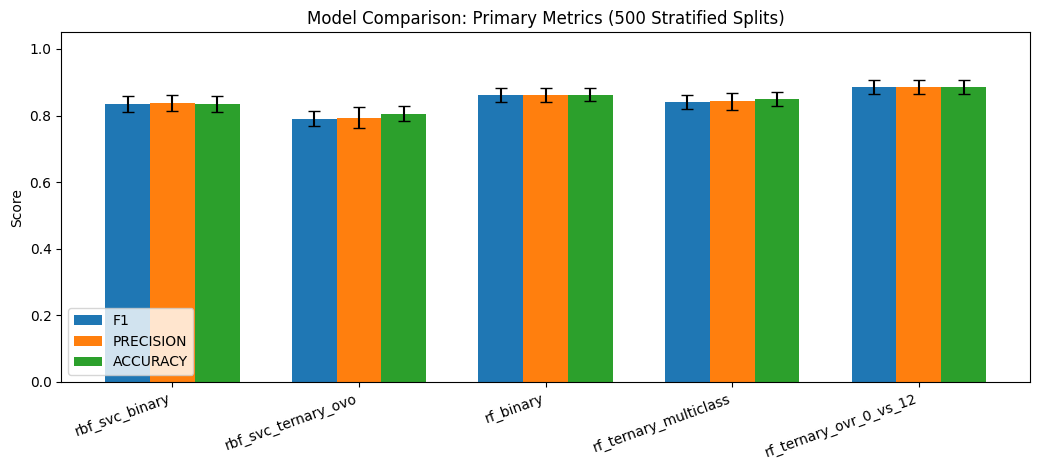

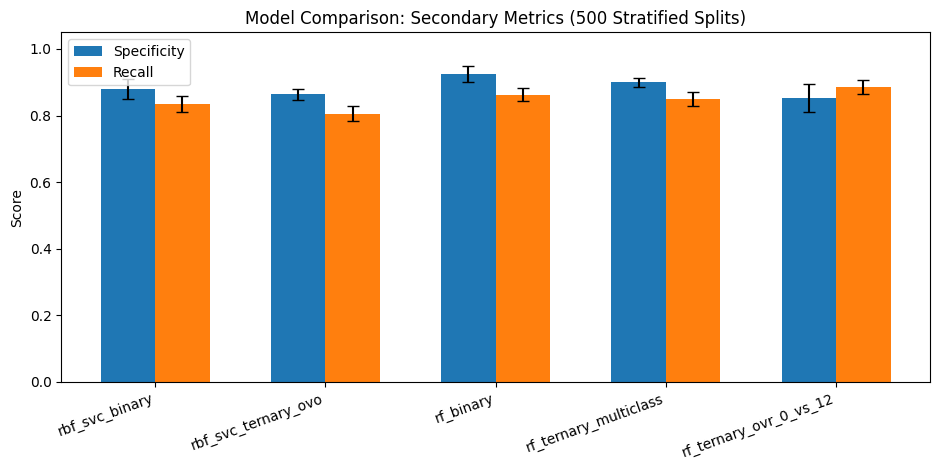

In [16]:
primary_metrics = ["f1", "precision", "accuracy"]
secondary_metrics = ["specificity", "recall"]
model_names = list(model_performance.keys())

fig, ax = plt.subplots(figsize=(10.5, 4.8))
positions = np.arange(len(model_names))
width = 0.24
offsets = np.linspace(-width, width, len(primary_metrics))
for metric_name, offset in zip(primary_metrics, offsets):
    means = [model_performance[model_name][metric_name]["mean"] for model_name in model_names]
    stds = [model_performance[model_name][metric_name]["std"] for model_name in model_names]
    ax.bar(positions + offset, means, width=width, yerr=stds, capsize=4, label=metric_name.upper())
ax.set_xticks(positions)
ax.set_xticklabels(model_names, rotation=20, ha="right")
ax.set_ylim(0.0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Model Comparison: Primary Metrics (500 Stratified Splits)")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9.5, 4.8))
positions = np.arange(len(model_names))
width = 0.32
offsets = np.linspace(-width / 2, width / 2, len(secondary_metrics))
for metric_name, offset in zip(secondary_metrics, offsets):
    means = [model_performance[model_name][metric_name]["mean"] for model_name in model_names]
    stds = [model_performance[model_name][metric_name]["std"] for model_name in model_names]
    ax.bar(positions + offset, means, width=width, yerr=stds, capsize=4, label=metric_name.capitalize())
ax.set_xticks(positions)
ax.set_xticklabels(model_names, rotation=20, ha="right")
ax.set_ylim(0.0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Model Comparison: Secondary Metrics (500 Stratified Splits)")
ax.legend()
plt.tight_layout()
plt.show()